# LeetCode #18: 4Sum

https://leetcode.com/problems/4sum/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^4)$ | $O(1)$ |
| **Sorting + Two Pointers** ★ | $O(n^3)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Try every combination of four indices with four nested loops. Sorting enables duplicate skipping but the $O(n^4)$ scan is too slow for $n > 50$.

### Optimal: Sorting + Two Pointers ★
Sort the array, fix outer indices i and j, then run a two-pointer sweep on the remaining window [j+1, n−1]. Skip duplicate values at each level so every quadruplet in the output is unique.

**Why this is better than Brute Force:** Replaces the two innermost loops with a single $O(n)$ sweep, dropping total time from $O(n^4)$ to $O(n^3)$. Sorting also makes duplicate skipping an $O(1)$ index comparison.

**Constraints:**
* 1 ≤ nums.length ≤ 200
* $-10^9$ ≤ nums[i] ≤ $10^9$
* $-10^9$ ≤ target ≤ $10^9$

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<IList<int>> FourSum(int[] nums, int target) {
        Array.Sort(nums);
        var result = new List<IList<int>>();
        int n = nums.Length;

        for (int i = 0; i < n - 3; i++) {
            if (i > 0 && nums[i] == nums[i - 1]) continue;
            for (int j = i + 1; j < n - 2; j++) {
                if (j > i + 1 && nums[j] == nums[j - 1]) continue;
                int left = j + 1, right = n - 1;
                while (left < right) {
                    // Cast to long to prevent overflow at boundary values
                    long sum = (long)nums[i] + nums[j] + nums[left] + nums[right];
                    if (sum == target) {
                        result.Add(new List<int> { nums[i], nums[j], nums[left], nums[right] });
                        while (left < right && nums[left] == nums[left + 1]) left++;
                        while (left < right && nums[right] == nums[right - 1]) right--;
                        left++; right--;
                    } else if (sum < target) {
                        left++;
                    } else {
                        right--;
                    }
                }
            }
        }
        return result;
    }
}

### Python

In [ ]:
class Solution:
    def fourSum(self, nums: List[int], target: int) -> List[List[int]]:
        nums.sort()
        result = []
        n = len(nums)

        for i in range(n - 3):
            if i > 0 and nums[i] == nums[i - 1]:
                continue
            for j in range(i + 1, n - 2):
                if j > i + 1 and nums[j] == nums[j - 1]:
                    continue
                left, right = j + 1, n - 1
                while left < right:
                    total = nums[i] + nums[j] + nums[left] + nums[right]
                    if total == target:
                        result.append([nums[i], nums[j], nums[left], nums[right]])
                        while left < right and nums[left] == nums[left + 1]:
                            left += 1
                        while left < right and nums[right] == nums[right - 1]:
                            right -= 1
                        left += 1
                        right -= 1
                    elif total < target:
                        left += 1
                    else:
                        right -= 1
        return result

### Go

In [ ]:
func fourSum(nums []int, target int) [][]int {
    sort.Ints(nums)
    result := [][]int{}
    n := len(nums)

    for i := 0; i < n-3; i++ {
        if i > 0 && nums[i] == nums[i-1] {
            continue
        }
        for j := i + 1; j < n-2; j++ {
            if j > i+1 && nums[j] == nums[j-1] {
                continue
            }
            left, right := j+1, n-1
            for left < right {
                // Cast to int64 to prevent overflow at boundary values
                sum := int64(nums[i]) + int64(nums[j]) + int64(nums[left]) + int64(nums[right])
                if sum == int64(target) {
                    result = append(result, []int{nums[i], nums[j], nums[left], nums[right]})
                    for left < right && nums[left] == nums[left+1] {
                        left++
                    }
                    for left < right && nums[right] == nums[right-1] {
                        right--
                    }
                    left++
                    right--
                } else if sum < int64(target) {
                    left++
                } else {
                    right--
                }
            }
        }
    }
    return result
}

### Rust

In [ ]:
pub fn four_sum(mut nums: Vec<i32>, target: i32) -> Vec<Vec<i32>> {
    nums.sort();
    let mut result = Vec::new();
    let n = nums.len();

    for i in 0..n.saturating_sub(3) {
        if i > 0 && nums[i] == nums[i - 1] { continue; }
        for j in (i + 1)..n.saturating_sub(2) {
            if j > i + 1 && nums[j] == nums[j - 1] { continue; }
            let (mut left, mut right) = (j + 1, n - 1);
            while left < right {
                // Cast to i64 to prevent overflow at boundary values
                let sum = nums[i] as i64 + nums[j] as i64 + nums[left] as i64 + nums[right] as i64;
                match sum.cmp(&(target as i64)) {
                    std::cmp::Ordering::Equal => {
                        result.push(vec![nums[i], nums[j], nums[left], nums[right]]);
                        while left < right && nums[left] == nums[left + 1] { left += 1; }
                        while left < right && nums[right] == nums[right - 1] { right -= 1; }
                        left += 1;
                        right -= 1;
                    }
                    std::cmp::Ordering::Less    => left += 1,
                    std::cmp::Ordering::Greater => right -= 1,
                }
            }
        }
    }
    result
}

## Example Scenarios

**1. Common Case**
**Input:** nums = [1, 0, -1, 0, -2, 2], target = 0 → sorted: [-2, -1, 0, 0, 1, 2]
i=0(−2), j=1(−1): left=2(0), right=5(2) → sum=−1, left++; left=3(0), right=5(2) → sum=−1, left++; left=4(1), right=5(2) → sum=0 ✓ → [−2,−1,1,2]; i=0, j=2(0): → [−2,0,0,2]; i=1(−1), j=2(0): → [−1,0,0,1]. Output: 3 quadruplets.

**2. Slightly Complex — all duplicates**
**Input:** nums = [2, 2, 2, 2, 2], target = 8 → sorted: [2,2,2,2,2]
i=0(2), j=1(2): left=2(2), right=4(2) → sum=8 ✓ → [2,2,2,2]. Duplicate-skip advances left past all 2s, loop ends. i=1 skipped (same as i=0). Output: [[2,2,2,2]].

**3. Edge Case: Time Factor — target beyond range**
**Input:** nums = [0,0,0,...,0] (200 zeros), target = 1
Every (i,j) pair launches a two-pointer scan; sum always 0 < 1, so left advances until left ≥ right each time. Full $O(n^3)$ sweep with zero matches. Output: [].

**4. Edge Case: Space Factor — many quadruplets**
**Input:** nums = [-2,-1,0,1,2,3], target = 2 → produces 5 unique quadruplets.
Each found quadruplet is appended to result; the output list is the only extra memory used — $O(k)$ where k is the number of quadruplets.

**5. Almost-Impossible but Plausible — overflow boundary**
**Input:** nums = [-1000000000, -1000000000, 1000000000, 1000000000], target = 0
sum = $-10^9 + (-10^9) + 10^9 + 10^9 = 0$. Using 32-bit int arithmetic this overflows ($-2 \times 10^9$ underflows int); casting to int64/long first gives the exact result. Output: [[-1000000000,-1000000000,1000000000,1000000000]].

## Infographic

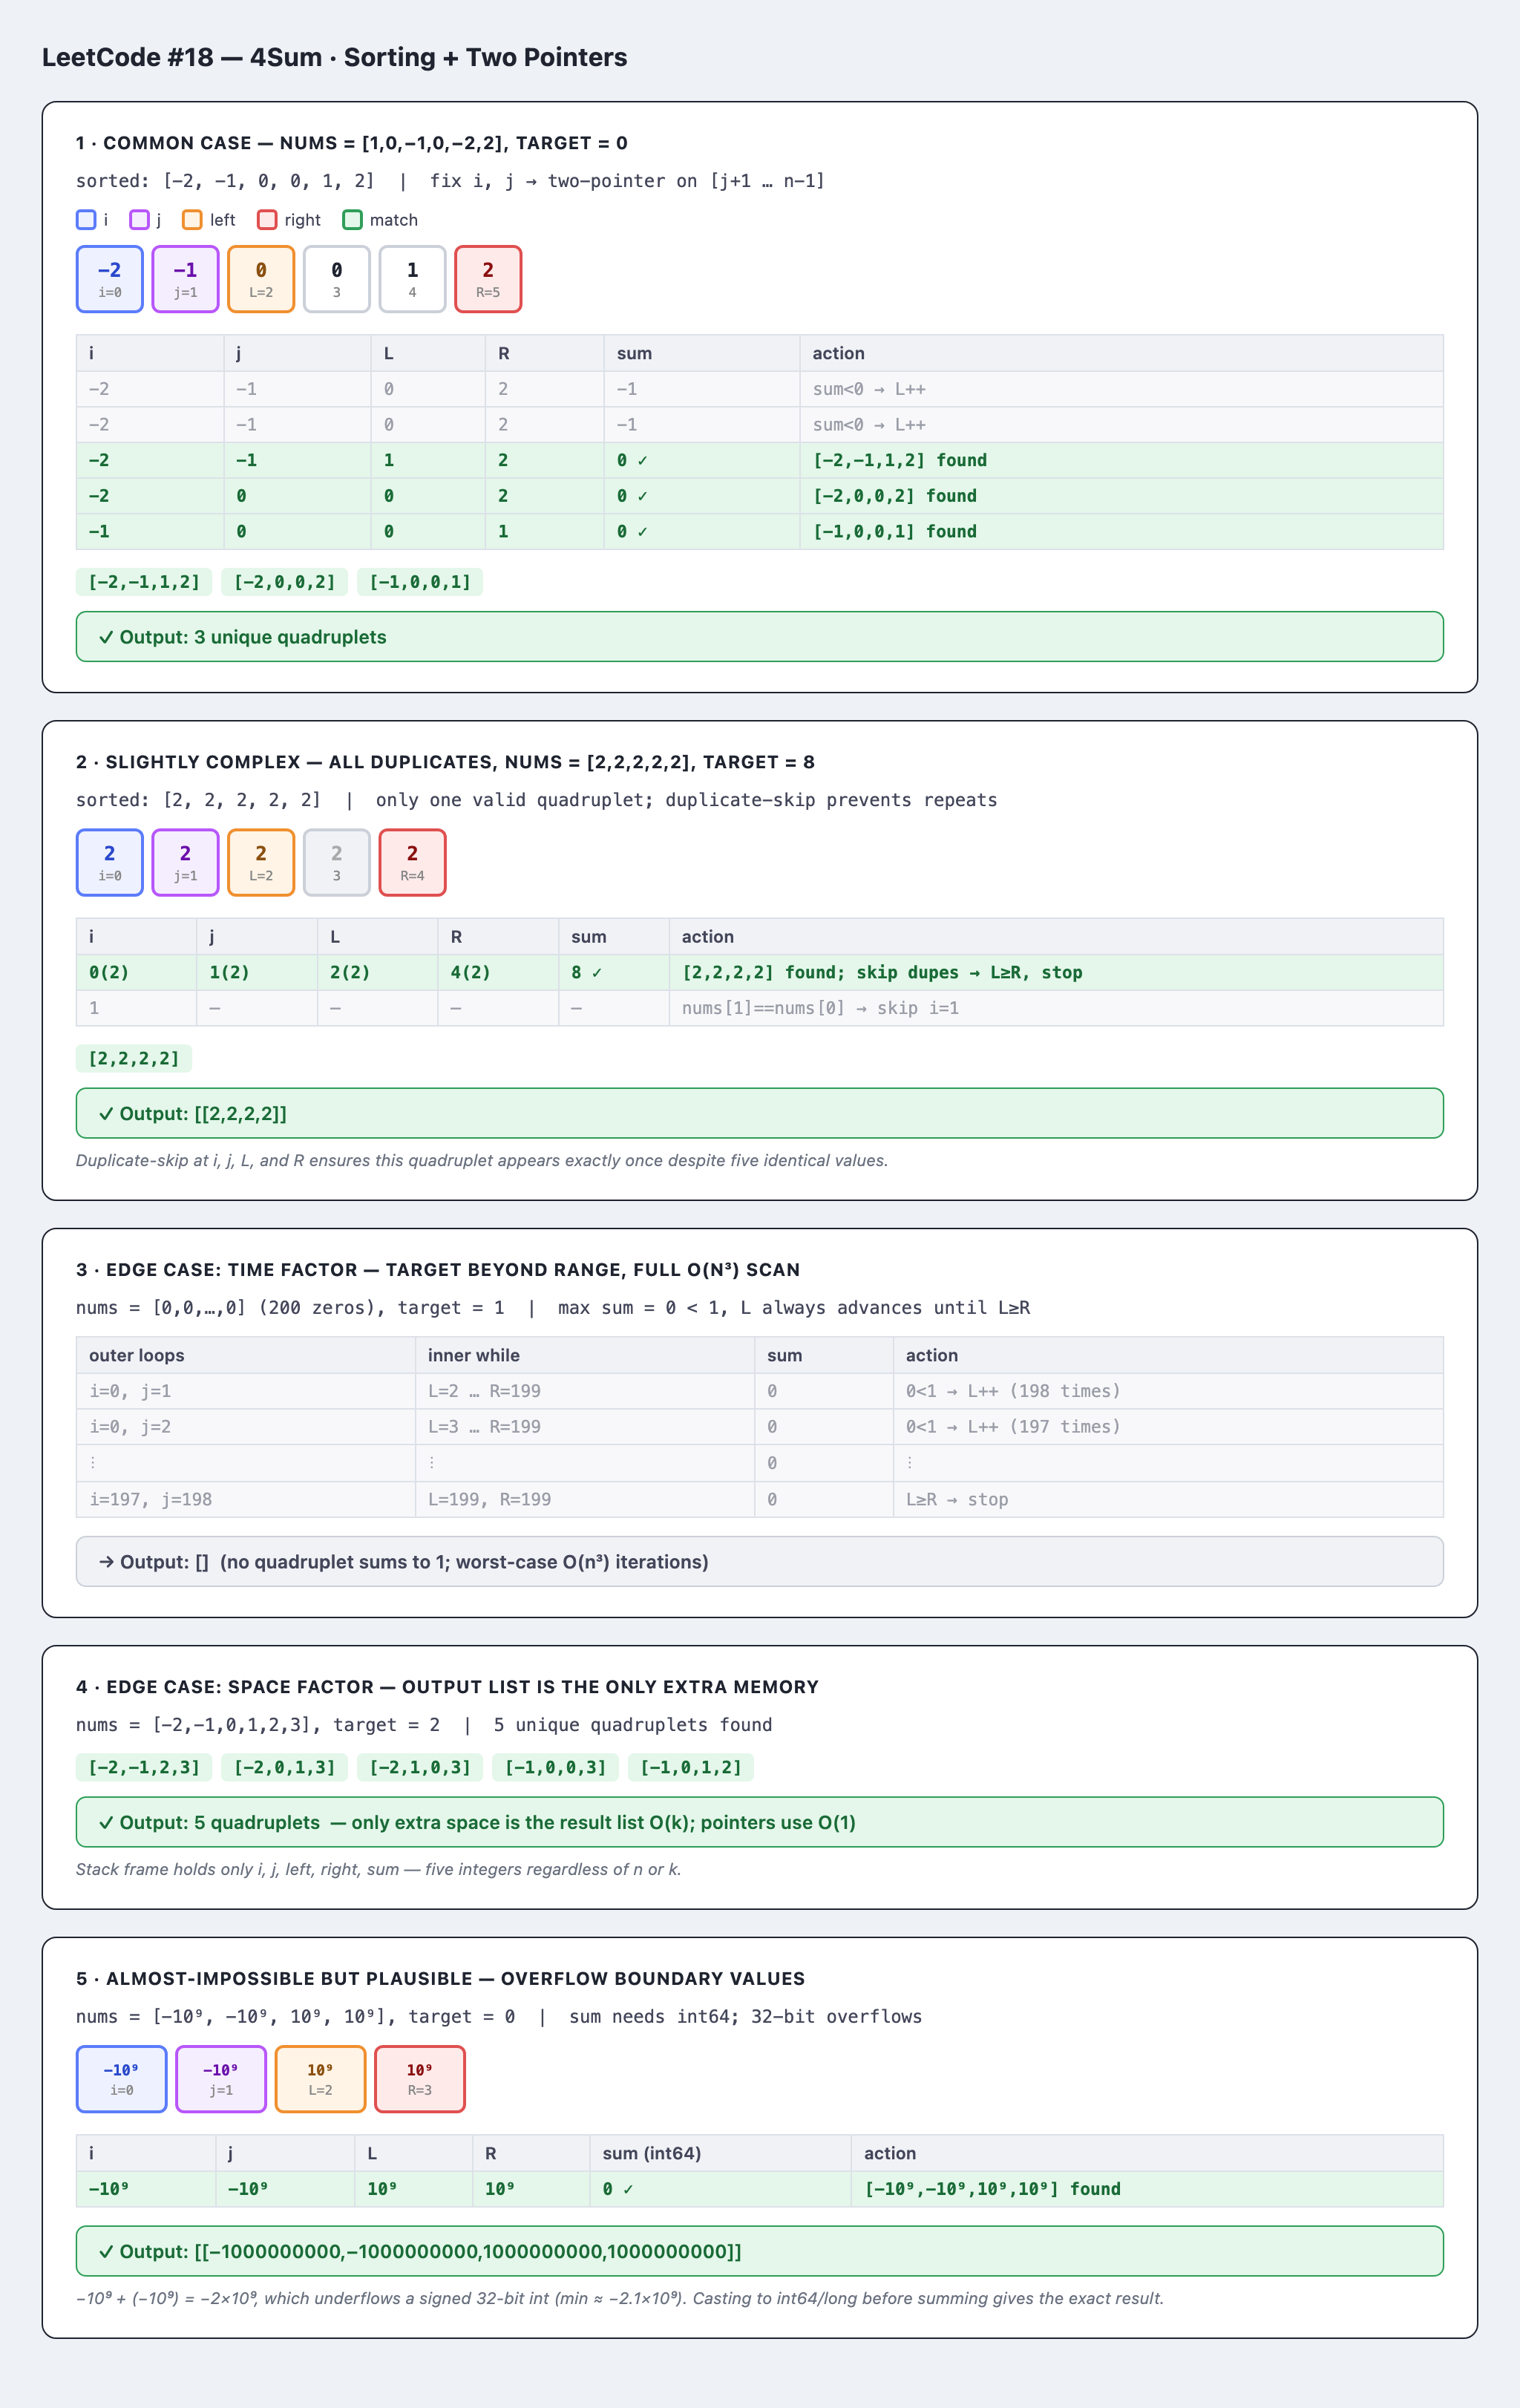